# Lab 04: Decision Tree & Random Forest

**ID:** 22302421

**Name:** Nguyễn Phúc Minh Châu

In [8]:
#Librabries
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, precision_score, recall_score
import numpy as np

#Load dataset
df = pd.read_csv('dataset.csv')
df

,Output (S),Ia,Ib,Ic,Va,Vb,Vc,Unnamed: 7,Unnamed: 8
0,0,-170.472196,9.219613,161.252583,0.054490,-0.659921,0.605431,NaN,NaN
1,0,-122.235754,6.168667,116.067087,0.102000,-0.628612,0.526202,NaN,NaN
2,0,-90.161474,3.813632,86.347841,0.141026,-0.605277,0.464251,NaN,NaN
3,0,-79.904916,2.398803,77.506112,0.156272,-0.602235,0.445963,NaN,NaN
4,0,-63.885255,0.590667,63.294587,0.180451,-0.591501,0.411050,NaN,NaN
...,...,...,...,...,...,...,...,...,...
11996,0,-66.237921,38.457041,24.912239,0.094421,-0.552019,0.457598,NaN,NaN
11997,0,-65.849493,37.465454,25.515675,0.103778,-0.555186,0.451407,NaN,NaN
11998,0,-65.446698,36.472055,26.106554,0.113107,-0.558211,0.445104,NaN,NaN
11999,0,-65.029633,35.477088,26.684731,0.122404,-0.561094,0.438690,NaN,NaN


### 1.Use Decision Tree (DT) (gini index) to detect faults in a power system. Compute the accuracy, precision, recall, F1   

In [4]:
X = df.iloc[:, 1:-2]  # Features
y = df.iloc[:, 0]      # Target

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

dt_tree = DecisionTreeClassifier(criterion='gini',random_state=42)
dt_tree.fit(X_train, y_train)

y_pred = dt_tree.predict(X_test)

scores = {
    'Accuracy': [accuracy_score(y_test, y_pred)],
    'Precision': [precision_score(y_test, y_pred)],
    'Recall': [recall_score(y_test, y_pred)],
    'F1': [f1_score(y_test, y_pred)]
}

tree_report = pd.DataFrame(scores)
tree_report

,Accuracy,Precision,Recall,F1
0,0.995419,0.993625,0.996347,0.994984


### 2. Now, use Random Forest (RF) to detect faults in a power system. Compare the performances of RF from using different trees: 10 trees, 100 trees and 500 trees. Does the accuracy improve when more DT are used?  Compute the RF accuracy, precision, recall, F1. 

In [5]:
n_trees = [10, 100, 500]
results = {}

for n in n_trees:
    df_forest = RandomForestClassifier(n_estimators=n, random_state=42)
    df_forest.fit(X_train, y_train)
    y_pred = df_forest.predict(X_test)

    results[n] = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1': f1_score(y_test, y_pred)
    }

forest_report = pd.DataFrame(results).T
forest_report

,Accuracy,Precision,Recall,F1
10,0.997085,0.996350,0.997260,0.996805
100,0.997501,0.996354,0.998174,0.997263
500,0.997918,0.996357,0.999087,0.997720


### 3.Compare DT and RF. Does RF outperform DT?

Looking at the Tree Report (DT) and Forest Report (RF), it is easy to see that all scores in the Forest Report (RF) are higher than those in the Tree Report (DT) by approximately 0.002–0.003. This small difference margin reflects that RF indeed outperforms DT.

### 4. Now, use 100 trees, but max_depth, the maximum depth of the tree, is restricted to 3.  Compute the RF accuracy.

In [7]:
forest_restricted = RandomForestClassifier(n_estimators=100, max_depth=3, random_state=42)
forest_restricted.fit(X_train, y_train)
y_pred_restricted = forest_restricted.predict(X_test)

print("Random Forest accuracy score with max_depth=3:", 
      accuracy_score(y_test, y_pred_restricted))

Random Forest accuracy score with max_depth=3: 0.9779258642232403


### 5. Feature importance: Use RandomForestClassifier.feature_importances_ to rank features of the dataset 
(For more information: https://scikit-learn.org/stable/auto_examples/ensemble/plot_forest_importances.html)

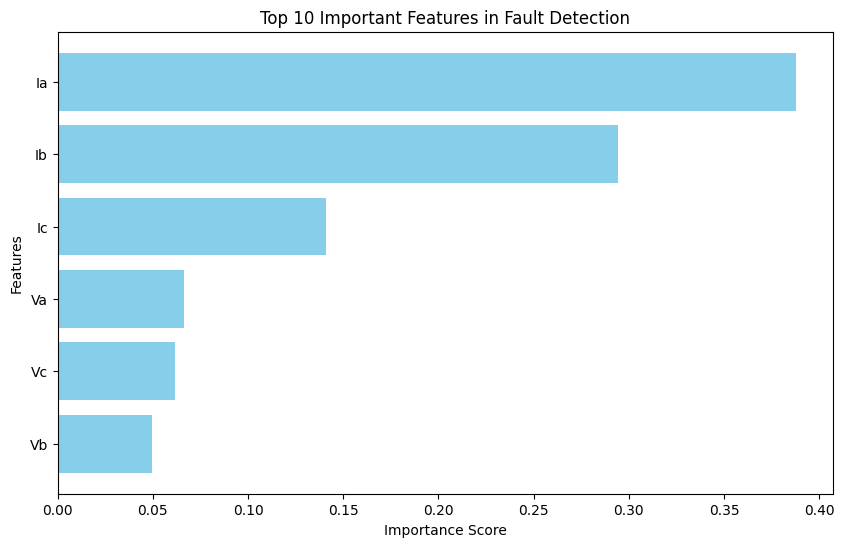

,Feature,Importance
0,Ia,0.387655
1,Ib,0.294113
2,Ic,0.140731
3,Va,0.066128
5,Vc,0.061729
4,Vb,0.049645


In [14]:
importance = df_forest.feature_importances_

feature_name = X.columns
feature_importance = pd.DataFrame({
    'Feature': feature_name,
    'Importance': importance
})

feature_importance = feature_importance.sort_values(by="Importance", ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'][:10], 
         feature_importance['Importance'][:10], color='skyblue')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.title('Top 10 Important Features in Fault Detection')
plt.gca().invert_yaxis()
plt.show()

feature_importance

### 6. Now drop the least important feature. Train RF model and compute the accuracy. Is there any improvement? 

In [16]:
least_important_feature = feature_importance.iloc[-1]['Feature']
print(f"Dropping the least important feature: {least_important_feature}")

X_train_reduced = X_train.drop(columns=[least_important_feature])
X_test_reduced = X_test.drop(columns=[least_important_feature])

forest_reduced = RandomForestClassifier(n_estimators=100, random_state=42)
forest_reduced.fit(X_train_reduced, y_train)

y_pred_reduced = forest_reduced.predict(X_test_reduced)

print(f"Accuracy after dropping '{least_important_feature}':", 
      accuracy_score(y_test, y_pred_reduced))

Dropping the least important feature: Vb
Accuracy after dropping 'Vb': 0.9966680549770929


Yes, there is a notable improvement. After dropping the 'Vb' feature, the accuracy increased from 0.9779 to 0.9967. This suggests that 'Vb' may have introduced noise, and removing it allowed the model to generalize better and focus on more predictive features.